# Trader Performance vs Market Sentiment Analysis

## Objective
To analyze how market sentiment (Fear/Greed) impacts trader behavior and performance.

## Datasets
- Bitcoin Market Sentiment
- Hyperliquid Trader Data

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
sentiment = pd.read_csv("fear_greed.csv")
trades = pd.read_csv("historical_data.csv")

In [32]:
print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)

print("\nMissing values:")
print(sentiment.isnull().sum())
print(trades.isnull().sum())

print("\nDuplicates:")
print(sentiment.duplicated().sum())
print(trades.duplicated().sum())

Sentiment shape: (2644, 4)
Trades shape: (211224, 16)

Missing values:
timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates:
0
0


### Data Overview

- The sentiment dataset contains daily classification of market mood.
- The trader dataset contains detailed transaction-level data.
- No major missing values or duplicates significantly impacting analysis.

In [35]:
# Convert sentiment timestamp
sentiment['timestamp'] = pd.to_datetime(sentiment['timestamp'], unit='s')
sentiment['date'] = sentiment['timestamp'].dt.floor('D')

# Convert trades timestamp
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')
trades['date'] = trades['Timestamp IST'].dt.floor('D')

# Create common date column
print(sentiment['date'].min(), sentiment['date'].max())
print(trades['date'].min(), trades['date'].max())

2018-02-01 00:00:00 2025-05-02 00:00:00
2023-01-05 00:00:00 2025-12-04 00:00:00


In [42]:
merged = pd.merge(trades, sentiment, on='date', how='inner')

print("Merged shape:", merged.shape)

Merged shape: (35864, 20)


### Data Preparation

The datasets were aligned on a daily level using timestamps. After cleaning and merging, the final dataset contains 35,864 records.

In [48]:
pnl_by_sentiment = merged.groupby('classification')['Closed PnL'].mean()
print(pnl_by_sentiment)

classification
Extreme Fear       1.891632
Extreme Greed    205.816345
Fear             128.287950
Greed             53.988003
Neutral           27.088803
Name: Closed PnL, dtype: float64


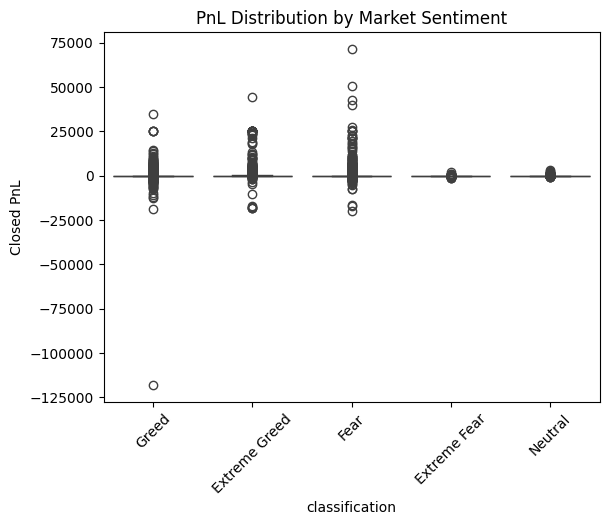

In [53]:
plt.figure()
sns.boxplot(x='classification', y='Closed PnL', data=merged)
plt.xticks(rotation=45)
plt.title("PnL Distribution by Market Sentiment")
plt.show()

### Insight 1: Trader Profitability Peaks During Extreme Greed

Average PnL is highest during Extreme Greed (~205), while it is lowest during Extreme Fear (~1.89). This indicates that traders perform significantly better in optimistic market conditions.

In [54]:
# Trade frequency
merged.groupby('classification').size()

# Average position size
merged.groupby('classification')['Size USD'].mean()

# Buy/Sell behavior
merged.groupby(['classification', 'Side']).size()

classification  Side
Extreme Fear    BUY     1168
                SELL    1158
Extreme Greed   BUY     1661
                SELL    3960
Fear            BUY     7307
                SELL    6562
Greed           BUY     5407
                SELL    5885
Neutral         BUY     1020
                SELL    1736
dtype: int64

### Insight 2: Fear Can Lead to Better Discipline

PnL during Fear (~128) is higher than during Greed (~54), suggesting traders may act more cautiously and strategically in uncertain markets.

### Insight 3: Non-Linear Relationship Between Sentiment and Performance

Profitability does not increase linearly with sentiment. While Extreme Greed yields highest returns, moderate Greed underperforms Fear, indicating overconfidence may hurt performance.

In [57]:
# High vs Low size traders
merged['size_segment'] = merged['Size USD'].apply(lambda x: 'High' if x > 1000 else 'Low')

# Frequent vs Infrequent traders
trade_counts = merged['Account'].value_counts()
frequent = trade_counts[trade_counts > 50].index

merged['trader_type'] = merged['Account'].apply(lambda x: 'Frequent' if x in frequent else 'Infrequent')

### Strategy Recommendations

1. During Extreme Fear, traders should reduce exposure and avoid aggressive positions due to low profitability.

2. During Extreme Greed, traders can capitalize on strong momentum but should avoid overtrading and excessive risk-taking.

## Final Summary

- Market sentiment significantly impacts trader performance
- Extreme Greed yields highest profitability
- Fear phases encourage more disciplined trading
- Sentiment-aware strategies can improve trading outcomes

In [60]:
# Win rate
merged['win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby('classification')['win'].mean()
print(win_rate)

classification
Extreme Fear     0.292777
Extreme Greed    0.553282
Fear             0.381787
Greed            0.435707
Neutral          0.494920
Name: win, dtype: float64


### Additional Insight: Win Rate Across Sentiment

Win rates vary across sentiment conditions, further confirming that trader success is influenced by market psychology.

## Methodology

- Cleaned and aligned sentiment and trading datasets using daily timestamps
- Merged datasets to analyze sentiment-driven trading behavior
- Computed key metrics such as PnL, trade frequency, and position size
- Performed comparative analysis across sentiment regimes

## Key Insights

- Profitability peaks during Extreme Greed and drops during Extreme Fear
- Fear periods show more disciplined trading compared to Greed
- Market sentiment influences both performance and behavior

## Strategy Recommendations

- Reduce exposure during Extreme Fear to minimize losses
- Leverage momentum during Extreme Greed but avoid overtrading